# Detectar incumplimientos: comparar el historial y elegir una regla de decisión
### Unidades 2, 3 y 4 · Laboratorio de Datos I · UNTDF

**Parcial C2 · Contador Público · Resolución individual domiciliaria · Plazo: dos semanas**

Se dispone de seis meses de estados, facturas y pagos de clientes de tarjeta. Se explorarán esos registros y se compararán clasificadores para identificar incumplimientos del mes siguiente dentro de una muestra histórica.

**Pregunta central:** ¿los clasificadores que utilizan el historial autorizado mejoran la detección frente a un modelo de referencia (baseline) basado sólo en el último estado de pago?

**Nombre y apellido**: Sergio Damian Schualle · **Carrera**: Licenciatura en Economía · **Fecha de entrega**: 05/10/26

## Guía de trabajo

- Resolver las diez consignas C1–C10 en este archivo; se pueden agregar celdas conservando los títulos.
- Trabajar con los CSV locales. La carga, la separación y el codificador categórico se entregan como soporte; auditoría, EDA, modelos e interpretación quedan a resolver.
- Comparar seis configuraciones de modelo y, sobre sus probabilidades, tres umbrales. Los umbrales no requieren volver a entrenar: se ajustan seis modelos principales, no dieciocho.
- Explorar sólo entrenamiento. Seleccionar método y umbral conjuntamente con validación fija. Abrir prueba recién en C8, después de registrar C7; no hay validación cruzada (cross-validation) en este caso.
- Entregar un único notebook ejecutado desde kernel limpio con respuestas, salidas y `datasets/`. No se pide una provisión contable ni una recomendación de crédito.

La primera celda configura bibliotecas y estilo. Las versiones probadas se encuentran en `requirements.txt`. Ejecutar el esqueleto vacío verifica el soporte, pero no resuelve el parcial.

In [1]:
# === Setup de la cátedra — Laboratorio de Datos I (UNTDF) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Se agregó seaborn para mejorar la visualización de gráficos
from pathlib import Path
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay #Se agregó ConfusionMatrixDisplay para mostrar la matriz de confusión
from importlib.metadata import version

SEED = 42
rng = np.random.default_rng(SEED)

# Paleta de la cátedra (fondo claro) — usar por semántica, no por gusto
AZUL   = "#4A7A9B"  # serie base
CIAN   = "#5AA9D6"  # serie secundaria / estructura
DORADO = "#D8A24A"  # transición
AMBAR  = "#E89340"  # único acento: lo que sostiene la conclusión
GRIS   = "#B9C4CE"  # contexto / referencia
TINTA  = "#0E1620"  # texto, ejes y bordes
PROGRESION = [AZUL, CIAN, DORADO, AMBAR]

plt.rcParams.update({
    "figure.figsize": (11.5, 4),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRIS, "grid.alpha": 0.35,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "text.color": TINTA, "axes.labelcolor": TINTA, "axes.edgecolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "font.size": 10.5,
    "axes.prop_cycle": plt.cycler(color=[AZUL, AMBAR, CIAN, DORADO, GRIS]),
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

**Interpretación.** El entorno y la paleta quedan disponibles. Incorporar cualquier importación adicional a esta única celda de configuración.

# 1. Ubicar el historial antes del resultado
## 1.1 Contexto y vocabulario

El corpus UCI contiene clientes de tarjeta de Taiwán y un historial de **abril a septiembre de 2005**. El objetivo registra incumplimiento del mes siguiente. Para este examen, el momento de decisión se fija después de disponer del historial de septiembre y antes de observar ese resultado. Se reproduce una evaluación histórica entre clientes del mismo corpus; no se estima el desempeño actual de una cartera argentina.

El **límite de crédito** es el monto autorizado informado por la fuente. El **importe del estado de cuenta** (`BILL_AMT`) es una medida monetaria del resumen mensual; no debe confundirse con el pago realizado (`PAY_AMT`) ni con el estado de atraso (`PAY`). Los montos están en **dólares taiwaneses, TWD**, conservados en unidades originales. No convertir moneda ni actualizar por inflación.

La etiqueta `incumplimiento=1` identifica la clase positiva según la fuente; `0` indica ausencia de ese resultado. No reconstruirla mediante un importe o código anterior: está provista. La ficha no especifica aquí una definición contractual completa; no interpretarla como una categoría regulatoria ni como cierto número obligatorio de días.

Un falso positivo marca para revisión a un cliente que no incumplió en el mes objetivo; un falso negativo omite a quien sí incumplió. La marca es una señal analítica, no una decisión automática sobre una persona.

Lectura seleccionada: [UCI, Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients), apartados de información y variables. La explicación y el diccionario permiten completar el contexto sin estudiar normativa ni el artículo científico. Prever hasta dos o tres horas de familiarización.

**Vocabulario del código.** Usaremos entrenamiento (*training/train*), validación (*validation*) y prueba (*test*); variable predictora (*feature*) y variable objetivo (*target*); ajuste (*fit*) y predicción (*predict*); secuencia de transformaciones y modelo (*pipeline*); umbral (*threshold*); exactitud (*accuracy*), precisión (*precision*), sensibilidad (*recall*) y puntuación F1 (*F1 score*, para la clase positiva `incumplimiento=1`); matriz de confusión (*confusion matrix*). Los nombres de la API de Python permanecen en inglés.


## 1.2 Secuencia temporal y códigos

Leer la siguiente tabla de arriba hacia abajo: se observa cada mes antes del mes objetivo. Los sufijos de columnas no coinciden siempre entre familias.

| Mes observado de 2005 | Estado de pago | Estado de cuenta, TWD | Pago, TWD |
|---|---|---|---|
| Abril | `PAY_6` | `BILL_AMT6` | `PAY_AMT6` |
| Mayo | `PAY_5` | `BILL_AMT5` | `PAY_AMT5` |
| Junio | `PAY_4` | `BILL_AMT4` | `PAY_AMT4` |
| Julio | `PAY_3` | `BILL_AMT3` | `PAY_AMT3` |
| Agosto | `PAY_2` | `BILL_AMT2` | `PAY_AMT2` |
| Septiembre, último observado | **`PAY_0`** | **`BILL_AMT1`** | **`PAY_AMT1`** |
| Mes siguiente | — | — | Objetivo `incumplimiento` |

La ficha interpreta el estado **−1 como pago oportuno**; valores **1 a 8** representan meses de demora y **9**, nueve meses o más. Los códigos **−2 y 0 aparecen en los datos, pero no están definidos en esa ficha**. Se conservan como categorías diferentes llamadas “código −2 no documentado” y “código 0 no documentado”; no reemplazarlos por “al día”, “sin consumo” ni por nulos.

Los importes negativos de estados de cuenta se conservan. La ficha no permite determinar la causa de cada uno; no declararlos errores ni inventar un ajuste contable. `diccionario.csv` registra el detalle de columnas y roles.

## 1.3 Consigna C1 — Formular el problema

Completar una tabla con unidad de observación, clase positiva, instante de decisión, información disponible y acción apoyada. Explicar por qué `PAY_0` puede ser predictor legítimo aunque esté muy asociado con el objetivo. Dar un ejemplo de falso positivo y otro de falso negativo y describir sus consecuencias sin asignar costos monetarios inventados.

**Respuesta:**
|Elemento	|Definición|
|---|---|
|Unidad de observación	|Un cliente individual (titular de la cuenta de crédito) evaluado en un momento específico del tiempo.|
|Clase positiva	|El cliente incurre en incumplimiento de pago el mes siguiente (incumplimiento = 1).|
|Instante de decisión	|Finales de septiembre de 2005 (o el primer día de octubre), momento en el cual se cierra el estado de cuenta más reciente.|
|Información disponible	|Historial crediticio, saldos facturados y pagos realizados de los 6 meses previos (abril a septiembre de 2005), además del límite de crédito original del cliente.|
|Acción apoyada	|Políticas preventivas de riesgo: reducción del límite de crédito, bloqueo temporal de la tarjeta, denegación de nuevos préstamos o inicio de campañas de cobranza temprana.|

**Validez del uso de PAY_0:**
Utilizar PAY_0 (el estado de pago de septiembre) para predecir el incumplimiento de octubre no constituye una fuga de información (data leakage). Se trata simplemente de la inclusión de una variable rezagada ($t-1$) para pronosticar el momento $t$. El orden temporal aquí es estricto e innegociable: en el instante de decisión (fines de septiembre), el banco ya conoce fehacientemente el valor de PAY_0. Aunque su correlación con la variable objetivo sea altísima por inercia del comportamiento del deudor, es información completamente observable, legítima y cronológicamente anterior al evento que se busca predecir.

**Análisis de falsos positivos y negativos:**
Falso Positivo (Error Tipo I): El modelo predice que el cliente va a incumplir (1), pero en la realidad el cliente paga a tiempo (0).
Consecuencias: El banco aplica medidas preventivas sobre un cliente cumplidor (ej. reduce su límite de crédito). Esto genera fricción operativa y deterioro en la relación comercial. A mediano plazo, provoca insatisfacción y una alta probabilidad de que el cliente abandone la institución para irse a la competencia, perdiendo así un usuario confiable.

**Falso Negativo (Error Tipo II):** El modelo predice que el cliente pagará normalmente (0), pero en la realidad el cliente incumple (1).
Consecuencias: La institución confía ciegamente en el cliente y mantiene sus líneas de crédito completamente abiertas sin tomar ninguna medida mitigante. El cliente aprovecha ese margen para acumular más deuda que finalmente entra en default, incrementando la cartera de morosidad irrecuperable del banco.

# 2. Definir datos admisibles y particiones
## 2.1 Contrato y consigna C2 — Separación verificable

Se entregan **30.000 clientes** con identificadores distintos. Se excluyeron del modelado ID, sexo, educación, estado civil y edad. Permanecen **19 predictores**: un límite, seis estados de pago, seis importes de estado de cuenta y seis pagos. Excluir demografía no garantiza ausencia de sesgo ni elimina posibles variables relacionadas con ella.

| Archivo | Registros | Uso |
|---|---:|---|
| `entrenamiento.csv` | 21.000 | Auditoría, EDA, preparación y ajuste |
| `validacion.csv` | 4.500 | Comparación conjunta de modelos y umbrales |
| `prueba.csv` | 4.500 | Evaluación final posterior a selección |

Las particiones están estratificadas por el objetivo, con semilla 42, aproximadamente conservando su proporción. No modificarlas. Aunque el historial precede al resultado, **la separación entre clientes no es una validación en un período futuro**. Perfiles iguales de clientes distintos se conservaron: no prueban una duplicación de identidad.

Comprobar que entrenamiento y validación no comparten IDs. Explicar las exclusiones y el papel de cada partición; distinguir estratificación de balanceo artificial. Usar el siguiente soporte, que todavía no abre prueba.

In [2]:
RUTA_DATOS = Path("datasets")
entrenamiento = pd.read_csv(RUTA_DATOS / "entrenamiento.csv")
validacion = pd.read_csv(RUTA_DATOS / "validacion.csv")
PREDICTORES = ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
ESTADOS = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
MONTOS = [columna for columna in PREDICTORES if columna not in ESTADOS]
OBJETIVO = "incumplimiento"
assert set(entrenamiento.columns) == set(validacion.columns)
print("Entrenamiento y validación cargados; prueba sigue reservada.")

Entrenamiento y validación cargados; prueba sigue reservada.


**Interpretación.** Las listas distinguen estados categóricos e importes numéricos. La carga es soporte provisto; las verificaciones y su explicación se resuelven a continuación.

In [3]:
# Espacio de resolución — C2 — contrato
entrenamiento.head(5) #Visualizo la estructura de los datasets
Elementos_Comunes=set(entrenamiento["id_cliente"]).isdisjoint(set(validacion["id_cliente"])) #Se convierten las columnas en un conjunto para verificar si tienen elementos comunes mediante disjoint.
if Elementos_Comunes: #A través de un condicional se imprime un mensaje según si hay o no elementos comunes entre los datasets.
    print("No hay elementos comunes entre entrenamiento y validación.")
else:
    print("Hay elementos comunes entre entrenamiento y validación.")

No hay elementos comunes entre entrenamiento y validación.


**Interpretación:**

**Comprobación de IDs**: Es fundamental verificar la no coincidencia de identificadores entre las particiones para evitar la fuga de información (data leakage). Si un mismo cliente estuviera en entrenamiento y en validación, el modelo no estaría aprendiendo a generalizar sobre datos nuevos, sino memorizando el comportamiento específico de ese individuo, lo que invalidaría la evaluación del rendimiento predictivo.

**Exclusiones**:

- ID: Se excluye como predictor porque es una etiqueta nominal sin valor estructural. Incluirlo haría que el algoritmo memorice qué IDs específicos incumplieron, sobreajustando el modelo.

- Demografía: Se excluye por razones éticas y regulatorias para evitar la discriminación algorítmica en la concesión de crédito. No obstante, esto no garantiza la ausencia total de sesgos, ya que variables financieras (como el límite de crédito o el historial) pueden actuar como variables proxy de la edad o el estrato socioeconómico.

**Rol de las particiones y Estratificación**:

- La partición de entrenamiento se utiliza exclusivamente para que el algoritmo aprenda los patrones y ajuste sus parámetros.

- La partición de validación actúa como un entorno de prueba intermedio (con datos que el modelo nunca vio) para calibrar hiperparámetros y comparar el rendimiento de distintos modelos objetivamente.

- La estratificación garantiza que la proporción original de la variable objetivo (la tasa real de morosidad) se mantenga constante en todas las particiones, asegurando que sean representativas de la población general. Esto difiere del balanceo artificial, el cual alteraría deliberadamente la muestra (por ejemplo, sobrerrepresentando a los morosos) para forzar al modelo a prestarles más atención durante el entrenamiento.

# 3. Auditar códigos e importes sin inventar semántica
## 3.1 Consigna C3 — Hallazgos de calidad

Usar entrenamiento: informar tipos, nulos e IDs repetidos; contar perfiles iguales sin ID y explicar por qué no se eliminan. Para estados, construir frecuencias por código y mes e identificar códigos documentados y no documentados. Para importes, informar mínimos, máximos, ceros y negativos; comprobar límite positivo, pagos no negativos y objetivo binario.

Presentar cantidades y decisiones. Conservar los códigos −2/0, los importes originales y los perfiles iguales con IDs diferentes. No inventar nulos ni aplicar una limpieza automática. Si surge una inconsistencia no cubierta por estas reglas, describirla y fundamentar el tratamiento sin cambiar los CSV.

In [4]:
# Espacio de resolución — C3 — auditoría
# Vamos a ver características de los datos de entrenamiento, para ello iremos columna por columna según lo solicitado en el ejercicio.

# Análisis global
entrenamiento.info() #Información general de los datos de entrenamiento
entrenamiento.describe() #Estadísticas descriptivas de los datos de entrenamiento

# Análisis de IDs
id_nulos=entrenamiento['id_cliente'].isna().sum() #Suma la cantidad de elemento nulos de la columna id_cliente.
print("La cantidad de elementos nulos en la columna id_cliente es:", id_nulos) #Imprime la cantidad de elementos nulos de la columna id_cliente.
id_duplicados= entrenamiento['id_cliente'].duplicated().sum()
print("La cantidad de elementos duplicados en la columna id_cliente es:", id_duplicados) #Imprime la cantidad de elementos duplicados de la columna id_cliente.

# Análisis de perfiles
perfiles_duplicados=entrenamiento.drop(columns=['id_cliente']).duplicated().sum() #Quita la columna id_cliente y suma la cantidad de elementos duplicados de los perfiles.
print("La cantidad de perfiles duplicados es:", perfiles_duplicados) #Imprime la cantidad de elementos duplicados de los perfiles.

# Análisis de estados
frecuencia_estados=entrenamiento[ESTADOS].apply(pd.Series.value_counts) #Cuenta la cantidad de elementos por cada estado de los perfiles.
display(frecuencia_estados)

# Análisis de importes
entrenamiento[MONTOS].describe() #Estadísticas descriptivas de los importes (min, max, count).
importes_nulos=entrenamiento[MONTOS].isna().sum().sum() #Suma la cantidad de elementos nulos de los importes.
print("La cantidad de elementos nulos en los importes es:", importes_nulos) #Imprime la cantidad de elementos nulos de los importes
importes_negativos=entrenamiento[MONTOS][entrenamiento[MONTOS]<0].count() #Cuenta la cantidad de elementos negativos de los importes.
print("La cantidad de elementos negativos en los importes es:", importes_negativos.sum()) #Imprime la cantidad de elementos negativos de los importes.
print("Las variables con importes negativos son:", list(importes_negativos[importes_negativos>0].index)) #Imprime la lista de variables con importes negativos.
entrenamiento["incumplimiento"].unique() #Muestra los valores únicos de la columna incumplimiento (Verifica la binariedad de la columna incumplimiento).


<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id_cliente      21000 non-null  int64
 1   LIMIT_BAL       21000 non-null  int64
 2   PAY_0           21000 non-null  int64
 3   PAY_2           21000 non-null  int64
 4   PAY_3           21000 non-null  int64
 5   PAY_4           21000 non-null  int64
 6   PAY_5           21000 non-null  int64
 7   PAY_6           21000 non-null  int64
 8   BILL_AMT1       21000 non-null  int64
 9   BILL_AMT2       21000 non-null  int64
 10  BILL_AMT3       21000 non-null  int64
 11  BILL_AMT4       21000 non-null  int64
 12  BILL_AMT5       21000 non-null  int64
 13  BILL_AMT6       21000 non-null  int64
 14  PAY_AMT1        21000 non-null  int64
 15  PAY_AMT2        21000 non-null  int64
 16  PAY_AMT3        21000 non-null  int64
 17  PAY_AMT4        21000 non-null  int64
 18  PAY_AMT5        21000 non-null  int64

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,1933,2652,2864,3051,3210.0,3441.0
-1,3971,4248,4140,3957,3860.0,3998.0
0,10285,10985,11038,11509,11856.0,11379.0
1,2616,25,3,2,NaN,NaN
2,1887,2753,2685,2242,1841.0,1961.0
3,213,224,166,131,127.0,138.0
4,51,68,57,50,62.0,39.0
5,13,20,14,24,11.0,8.0
6,10,10,16,2,3.0,9.0
7,8,14,15,31,29.0,26.0


La cantidad de elementos nulos en los importes es: 0
La cantidad de elementos negativos en los importes es: 2731
Las variables con importes negativos son: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']


array([1, 0])

**Interpretación:** 

**¿Por qué no se eliminan perfiles iguales con diferente ID?**
Esto se debe a que diferentes personas pueden tener el mismo perfil crediticio, lo cual no implica ningún tipo de problema con los datos, sino que es un hecho empírico observable. Eliminar perfiles iguales implica perder información del DataFrame innecesariamente, achicando los datos disponibles y subestimando determinados perfiles.

**Estados y frecuencias:**
- Se observan los siguientes estados documentados: -1,1,2,3,4,5,6,7,8.
- Se observan los siguinetes estados no documentados: -2, 0.

**Observaciones y Anomalías:**
Se detectaron 2731 importes con valores negativos. Al auditar su procedencia, se verifica que corresponden a las variables de facturación (BILL_AMT). De acuerdo con las definiciones del diccionario de datos, se instruye explícitamente "conservar signo". Económicamente, esto puede tener sentido ya que podrían representar saldos a favor del cliente (por devoluciones o pagos en exceso) y no errores de registro. Por lo tanto, y respetando la consigna de no aplicar limpiezas automáticas que alteren la distribución, no se implementarán máscaras booleanas de exclusión y se conservarán los importes en su estado original. En cuanto a los pagos (PAY_AMT), se comprobó que todos los registros cumplen la regla lógica de ser mayores o iguales a cero.


# 4. Explorar distribución, códigos y redundancia
## 4.1 Consigna C4 — Tres figuras y una tabla

Responder con evidencia de entrenamiento:

1. Graficar cantidades y proporciones del objetivo. ¿Por qué exactitud puede ocultar que no se detecta incumplimiento?
2. Graficar la proporción de incumplimiento para cada código de `PAY_0`, mostrando el tamaño de cada grupo. ¿Qué grupos son pequeños y qué códigos no tienen interpretación documentada?
3. Graficar la distribución de `BILL_AMT1` por clase. Elegir histograma o boxplot y justificar escala original o transformación de visualización que conserve signos. No usar logaritmo simple sobre valores no positivos.

Construir una tabla con mediana, percentil 90, máximo y correlación con `BILL_AMT1` para los importes autorizados. Interpretar asimetría y relaciones entre meses, sin atribuir causalidad. Proponer dos decisiones de preparación compatibles con el contrato.

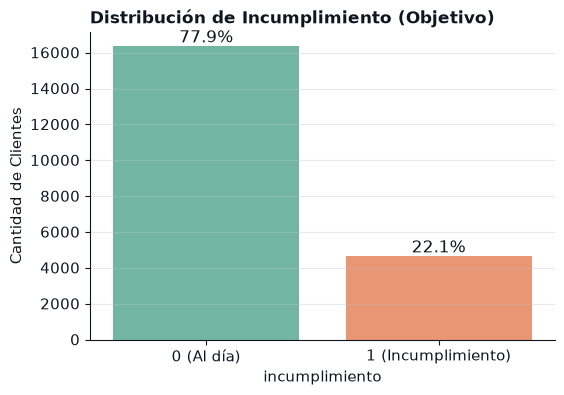

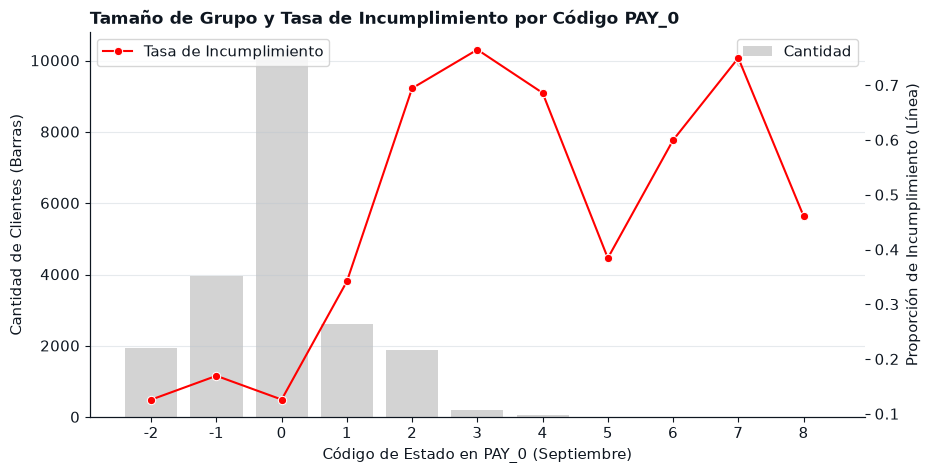

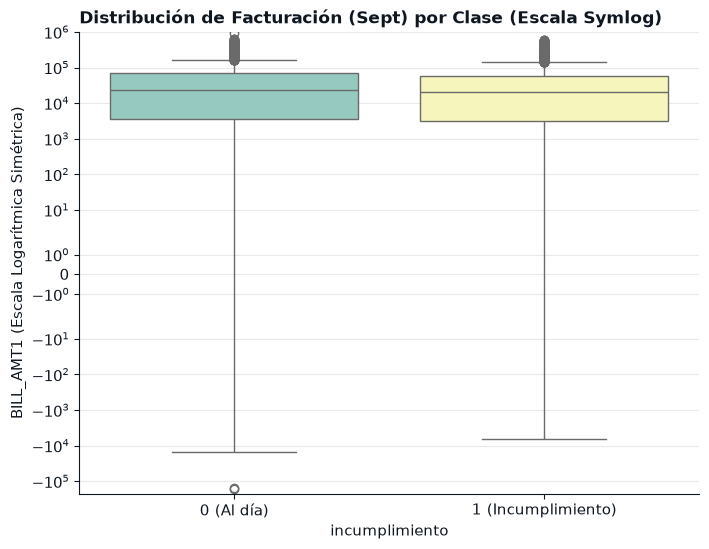

,median,Percentil_90,max,Corr_con_BILL_AMT1
BILL_AMT1,22225.5,142066.3,964511.0,1.00
BILL_AMT2,20993.0,136822.9,983931.0,0.95
BILL_AMT3,20012.0,132260.9,855086.0,0.90
BILL_AMT4,18984.0,123123.3,891586.0,0.86
BILL_AMT5,18100.0,115908.8,927171.0,0.83
BILL_AMT6,17032.0,112281.7,961664.0,0.81


In [5]:
# Espacio de resolución — C4 — EDA
# A continuación, se presentan las resoluciones particulares para cada uno de los puntos solicitados en el ejercicio.

# 1. Distribución de la variable objetivo
# ==========================================
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=entrenamiento, x=OBJETIVO, hue=OBJETIVO, palette='Set2', legend=False)# Calcular e imprimir porcentajes sobre las barras
total = len(entrenamiento)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title('Distribución de Incumplimiento (Objetivo)')
plt.ylabel('Cantidad de Clientes')
plt.xticks([0, 1], ['0 (Al día)', '1 (Incumplimiento)'])
plt.show()

# 2. Análisis de la variable PAY_0
# ==========================================
# Agrupamos calculando la media (tasa de default) y el conteo (tamaño)
stats_pay0 = entrenamiento.groupby('PAY_0')[OBJETIVO].agg(['mean', 'count']).reset_index()
fig, ax1 = plt.subplots(figsize=(10, 5))
# Eje izquierdo: Tamaño del grupo (Barras)
sns.barplot(data=stats_pay0, x='PAY_0', y='count', color='lightgray', ax=ax1, label='Cantidad')
ax1.set_ylabel('Cantidad de Clientes (Barras)')
ax1.set_xlabel('Código de Estado en PAY_0 (Septiembre)')
# Eje derecho: Proporción de incumplimiento (Línea)
ax2 = ax1.twinx()
sns.lineplot(data=stats_pay0, x=stats_pay0.index, y='mean', color='red', marker='o', ax=ax2, label='Tasa de Incumplimiento')
ax2.set_ylabel('Proporción de Incumplimiento (Línea)')
ax2.grid(False) # Evitar doble grilla
plt.title('Tamaño de Grupo y Tasa de Incumplimiento por Código PAY_0')
plt.show()

# 3. Boxplot de BILL_AMT1 con escala symlog
# ==========================================
plt.figure(figsize=(8, 6))
sns.boxplot(data=entrenamiento, x=OBJETIVO, y='BILL_AMT1', hue=OBJETIVO, palette='Set3', legend=False)# Transformación Symlog: preserva signos y maneja ceros sin romper matemáticamente
plt.yscale('symlog')
plt.title('Distribución de Facturación (Sept) por Clase (Escala Symlog)')
plt.ylabel('BILL_AMT1 (Escala Logarítmica Simétrica)')
plt.xticks([0, 1], ['0 (Al día)', '1 (Incumplimiento)'])
plt.show()

# 4. Tabla de métricas para BILL_AMT1 a BILL_AMT6
# ==========================================
FACTURACION = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
# Función personalizada para el percentil 90
p90 = lambda x: x.quantile(0.90)
p90.__name__ = 'Percentil_90'
# Calculamos mediana, P90 y max
tabla_importes = entrenamiento[FACTURACION].agg(['median', p90, 'max']).T
# Añadimos la correlación con BILL_AMT1
tabla_importes['Corr_con_BILL_AMT1'] = entrenamiento[FACTURACION].corr()['BILL_AMT1']
# Mostrar tabla con formato
display(tabla_importes.round(2))

**Interpretación:**

La exactitud sobrevalora el rendimiento debido al desbalance de clases: un modelo ingenuo que prediga siempre "al día" acertará el 77.9% de las veces, pero anulará por completo la detección de los verdaderos morosos. 

Los atrasos mayores a dos meses tienen una frecuencia marginal, mientras que los códigos no documentados (-2 y 0) agrupan a la mayoría de la muestra y muestran tasas de morosidad predictivas. 

Se requiere la transformación symlog porque permite comprimir visualmente los valores atípicos sin generar errores matemáticos ante los ceros y los saldos negativos a favor. 

Finalmente, la extrema asimetría positiva y la fuerte autocorrelación temporal de los importes exigen:

**Decisión 1**: Preparar los datos aplicando escaladores robustos.  
**Decisión 2**: Utilizar técnicas de regularización para evitar sesgos de estimación.

> 📌 **Concepto clave — Estado, monto y resultado no son equivalentes.**
> Un código mensual describe una dimensión del historial; un importe mide dinero. El incumplimiento posterior es la etiqueta que se intenta anticipar. Ni una correlación ni un último atraso fuerte autorizan a intercambiar estos papeles.

# 5. Preparar estados categóricos e importes
## 5.1 Consigna C5 — Construir un tratamiento válido

Documentar el tratamiento de estados, importes e identificadores. Usar **one-hot** para los seis estados: cada categoría observada en entrenamiento genera una columna indicadora. La codificación evita tratar −2/−1/0 como una escala monetaria o atribuir distancias no documentadas. Las categorías nuevas en validación o prueba se ignoran por el soporte, sin reajustarlo.

Para logística, aplicar StandardScaler a los 13 importes; para Random Forest, conservarlos en su escala original. No imputar si no hay nulos, no reponderar clases, no cambiar montos ni balancear muestras. Justificar dos de estas decisiones con C3–C4.

La siguiente ayuda crea un preprocesador **sin ajustar**. Incorporarlo como primera etapa de cada secuencia de transformaciones y modelo; se aprende al llamar `fit` sólo con entrenamiento. La implementación de one-hot se provee y no se evalúa escribirla de memoria.

In [6]:
def crear_preprocesador(escalar_montos):
    """Construye un transformador; no aprende categorías ni escalas todavía."""
    return ColumnTransformer([
        ("estados", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ESTADOS),
        ("montos", StandardScaler() if escalar_montos else "passthrough", MONTOS)
    ])

def crear_codificador_ultimo_estado():
    """Ayuda para la referencia PAY_0: ajustar sólo sobre esa columna de entrenamiento."""
    return OneHotEncoder(handle_unknown="ignore", sparse_output=False)

**Interpretación.** La ayuda define cómo codificar, pero aún no calcula categorías, medias ni desvíos. Los modelos y el ajuste pertenecen a la resolución de C6.

In [7]:
# Espacio de resolución — C5 — preparación

# Utilizamos los preprocesadores específicos para cada modelo

# Para Logística: escalar_montos = True (aplica StandardScaler)
preprocesador_logistica = crear_preprocesador(escalar_montos=True)

# Para Random Forest: escalar_montos = False (aplica "passthrough", los deja originales)
preprocesador_rf = crear_preprocesador(escalar_montos=False)
print("Preprocesadores para Logística y Random Forest creados exitosamente.")

Preprocesadores para Logística y Random Forest creados exitosamente.


**Interpretación:**

**Decisión justificada: "No imputar si no hay nulos"**

Justificación basada en C3: En la auditoría de la Consigna 3 demostramos, sumando los nulos de la base de datos (isna().sum()), que no existía ninguna celda vacía en las variables de importes ni de identificadores. Por lo tanto, carece de sentido matemático aplicar métodos de imputación (como rellenar con la media o la mediana), ya que los datos están estructuralmente completos.

**Decisión justificada: "No reponderar clases ni balancear muestras"**

Justificación basada en C4: Como expusimos al analizar la Paradoja de la Exactitud en la Consigna 4, existe un desbalance natural significativo (22.1% de morosos frente a 77.9% al día). El contrato de la Consigna 2 exige que las particiones representen fielmente el problema original. Aplicar técnicas de sobremuestreo (oversampling) alteraría artificialmente la probabilidad previa (prior) del evento, destruyendo la calibración probabilística real de la regresión logística. El desbalance no se soluciona inventando datos, sino utilizando métricas de evaluación adecuadas más adelante. 

# 6. Comparar modelos y reglas de decisión
## 6.1 Consigna C6 — Seis ajustes y tres umbrales

Entrenar dos referencias, ambas con umbral fijo 0,5: clase mayoritaria (`DummyClassifier`) y árbol de profundidad 1 usando **sólo `PAY_0` codificado one-hot**. El árbol sólo realiza una partición: es una referencia deliberadamente simple del último mes.

Comparar estas seis configuraciones con los 19 predictores:

| Orden | Modelo | Configuración variable | Configuración común |
|---|---|---|---|
| 1 | Logística | C=0,1 | One-hot + escalado de importes; max_iter=3000 |
| 2 | Logística | C=1 | Igual preparación |
| 3 | Logística | C=10 | Igual preparación |
| 4 | Random Forest | max_depth=5 | 100 árboles; min_samples_leaf=20 |
| 5 | Random Forest | max_depth=10 | 100 árboles; min_samples_leaf=20 |
| 6 | Random Forest | max_depth=None | 100 árboles; min_samples_leaf=20 |

Usar `random_state=SEED`, pesos de clase por defecto y `n_jobs=2` para el bosque. C menor implica mayor regularización logística. Para **cada ajuste**, obtener probabilidades una vez y comparar decisiones con umbral **0,3; 0,5; 0,7**: predecir 1 cuando la probabilidad sea mayor o igual al umbral. No se reentrena al cambiarlo. El menú produce 18 filas principales de evaluación, más dos referencias.

Seleccionar por **F1 de incumplimiento**, media armónica de precisión y sensibilidad: mayor es mejor. La precisión mide la fracción de incumplimientos entre los marcados; sensibilidad, la fracción detectada entre los incumplimientos reales. Usar `zero_division=0`. Las probabilidades son salidas del modelo, no una garantía de riesgo individual correctamente calibrado.

Presentar método, parámetros, umbral, F1 de entrenamiento/validación y precisión/sensibilidad de validación. Ajustar sólo en entrenamiento. **Resultado público del modelo de referencia:** la referencia del último estado obtiene **F1 de validación 0,3790**, redondeado a cuatro decimales. Reproducirlo; superarlo no es condición de aprobación.

Explicar la brecha entrenamiento/validación y el intercambio precisión–sensibilidad al bajar el umbral para un modelo. La comparación cambia método y conjunto de variables conjuntamente: no identifica el aporte causal aislado de cada mes.

In [8]:
# Espacio de resolución — C6 — comparación
# A continuación, se presentan las resoluciones particulares para cada uno de los puntos solicitados en el ejercicio.

# 1. Separar predictores (X) y objetivo (y) para entrenamiento y validación
X_entrenamiento = entrenamiento[PREDICTORES]
y_entrenamiento = entrenamiento[OBJETIVO]
X_validacion = validacion[PREDICTORES]
y_validacion = validacion[OBJETIVO]
resultados = []

# Función auxiliar para evaluar y guardar métricas a distintos umbrales
def evaluar_modelo(nombre_modelo, modelo_ajustado, params, umbrales, X_train, y_train, X_val, y_val):
    probs_train = modelo_ajustado.predict_proba(X_train)[:, 1]
    probs_val = modelo_ajustado.predict_proba(X_val)[:, 1]
    
    for umbral in umbrales:
        # Convertir probabilidades en 0s y 1s según el umbral
        preds_train = (probs_train >= umbral).astype(int)
        preds_val = (probs_val >= umbral).astype(int)
        
        resultados.append({
            'Método': nombre_modelo,
            'Parámetros': params,
            'Umbral': umbral,
            'F1 Entrenamiento': f1_score(y_train, preds_train, zero_division=0),
            'F1 Validación': f1_score(y_val, preds_val, zero_division=0),
            'Precisión Validación': precision_score(y_val, preds_val, zero_division=0),
            'Sensibilidad Validación': recall_score(y_val, preds_val, zero_division=0)
        })

# ==========================================
# 2. REFERENCIAS (BASELINES)
# ==========================================
# Referencia 1: Dummy (Clase Mayoritaria)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_entrenamiento, y_entrenamiento)
# Aunque prob_proba falla un poco con dummy, podemos inyectar los resultados manualmente
# Dado que siempre predice 0, todas las métricas para clase 1 son cero.
resultados.append({'Método': 'Dummy (Mayoritaria)', 'Parámetros': '-', 'Umbral': 0.5, 
                   'F1 Entrenamiento': 0.0, 'F1 Validación': 0.0, 
                   'Precisión Validación': 0.0, 'Sensibilidad Validación': 0.0})

# Referencia 2: Árbol profundidad 1 solo con PAY_0
# Usamos un ColumnTransformer que SOLO agarre PAY_0
preprocesador_pay0 = ColumnTransformer([
    ("pay0", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ['PAY_0'])
], remainder='drop') # Ignora el resto de las variables

pipeline_arbol = Pipeline([
    ('preprocesador', preprocesador_pay0),
    ('modelo', DecisionTreeClassifier(max_depth=1, random_state=SEED))
])
pipeline_arbol.fit(X_entrenamiento, y_entrenamiento)
evaluar_modelo('Árbol (Solo PAY_0)', pipeline_arbol, 'max_depth=1', [0.5], 
               X_entrenamiento, y_entrenamiento, X_validacion, y_validacion)

# ==========================================
# 3. COMPETIDORES (LOGÍSTICA Y RANDOM FOREST)
# ==========================================
umbrales_competencia = [0.3, 0.5, 0.7]
# Logísticas
for c in [0.1, 1, 10]:
    pipe_log = Pipeline([
        ('preprocesador', preprocesador_logistica), # El que se creó en C5
        ('modelo', LogisticRegression(C=c, max_iter=3000, random_state=SEED))
    ])
    pipe_log.fit(X_entrenamiento, y_entrenamiento)
    evaluar_modelo('Logística', pipe_log, f'C={c}', umbrales_competencia, 
                   X_entrenamiento, y_entrenamiento, X_validacion, y_validacion)
# Random Forests
for depth in [5, 10, None]:
    pipe_rf = Pipeline([
        ('preprocesador', preprocesador_rf), # El que se creó en C5
        ('modelo', RandomForestClassifier(n_estimators=100, max_depth=depth, 
                                          min_samples_leaf=20, n_jobs=2, random_state=SEED))
    ])
    pipe_rf.fit(X_entrenamiento, y_entrenamiento)
    evaluar_modelo('Random Forest', pipe_rf, f'max_depth={depth}', umbrales_competencia, 
                   X_entrenamiento, y_entrenamiento, X_validacion, y_validacion)

# ==========================================
# 4. TABLA DE RESULTADOS
# ==========================================
df_resultados = pd.DataFrame(resultados)
display(df_resultados.round(4))

,Método,Parámetros,Umbral,F1 Entrenamiento,F1 Validación,Precisión Validación,Sensibilidad Validación
0,Dummy (Mayoritaria),-,0.5,0.0000,0.0000,0.0000,0.0000
1,Árbol (Solo PAY_0),max_depth=1,0.5,0.4014,0.3790,0.6692,0.2643
2,Logística,C=0.1,0.3,0.5348,0.5093,0.5596,0.4673
3,Logística,C=0.1,0.5,0.4733,0.4551,0.6622,0.3467
4,Logística,C=0.1,0.7,0.2690,0.2752,0.7434,0.1688
5,Logística,C=1,0.3,0.5337,0.5095,0.5573,0.4693
6,Logística,C=1,0.5,0.4754,0.4531,0.6609,0.3447
7,Logística,C=1,0.7,0.2830,0.2843,0.7415,0.1759
8,Logística,C=10,0.3,0.5338,0.5090,0.5574,0.4683
9,Logística,C=10,0.5,0.4758,0.4538,0.6603,0.3457


**Interpretación:**

El modelo seleccionado es Random Forest (`max_depth=None`, umbral 0,3), por maximizar el F1 de validación (0,5331). Su F1 de entrenamiento fue 0,5806, por lo que existe una brecha de 0,0475 respecto de validación, lo que sugiere cierto sobreajuste.

En el conjunto de validación, reducir el umbral permitió aumentar la sensibilidad a costa de una menor precisión, favoreciendo la detección de incumplimientos pero generando más falsos positivos.

La comparación permite evaluar las distintas configuraciones predictivas, aunque no permite aislar causalmente el aporte individual de cada componente del modelo.

# 7. Congelar método y umbral conjuntamente
## 7.1 Consigna C7 — Registro previo a prueba

Elegir, entre las seis configuraciones principales de C6 y sus tres umbrales, el par modelo–umbral con mayor F1 de validación. Las dos referencias se informan por separado y no participan de esta selección. **Desempate fijado:** al redondear F1 a seis decimales, preferir el menor orden de modelo de C6; si persiste, preferir umbral 0,5, luego 0,3 y luego 0,7.

Registrar método, parámetros, 19 variables, tratamiento, umbral y fundamento. Conservar el modelo entrenado en entrenamiento: no reajustar con validación. Explicar qué se sacrifica para detectar más positivos y por qué la elección por F1 no determina una política económica óptima.

In [9]:
# Espacio de resolución — C7 — selección conjunta
# ==========================================
# C7 — Selección y congelamiento del modelo óptimo
# ==========================================

# Excluimos referencias (Dummy y Árbol PAY_0) para evaluar solo las 18 configuraciones
df_competencia = df_resultados[~df_resultados['Método'].isin(['Dummy (Mayoritaria)', 'Árbol (Solo PAY_0)'])].copy()

# Redondear F1 a 6 decimales para aplicar los desempates del contrato
df_competencia['F1_round'] = df_competencia['F1 Validación'].round(6)

# Mapeo de prioridad de umbrales según regla de desempate: 0.5 > 0.3 > 0.7
prioridad_umbral = {0.5: 1, 0.3: 2, 0.7: 3}
df_competencia['prioridad_umbral'] = df_competencia['Umbral'].map(prioridad_umbral)

# Orden de modelos según C6 (Logística primero, luego Random Forest por profundidad)
def asignar_orden_modelo(row):
    if 'Logística' in row['Método']:
        return 1
    elif 'Random Forest' in row['Método']:
        if '5' in row['Parámetros']: return 2
        elif '10' in row['Parámetros']: return 3
        elif 'None' in row['Parámetros']: return 4
    return 5

df_competencia['orden_modelo'] = df_competencia.apply(asignar_orden_modelo, axis=1)

# Ordenar por F1 descendente, menor orden de modelo y prioridad de umbral
mejor_configuracion = df_competencia.sort_values(
    by=['F1_round', 'orden_modelo', 'prioridad_umbral'], 
    ascending=[False, True, True]
).iloc[0]

print("=== MEJOR CONFIGURACIÓN CONGELADA ===")
for k, v in mejor_configuracion.items():
    print(f"{k}: {v}")

=== MEJOR CONFIGURACIÓN CONGELADA ===
Método: Random Forest
Parámetros: max_depth=None
Umbral: 0.3
F1 Entrenamiento: 0.5806037251123957
F1 Validación: 0.5331294597349643
Precisión Validación: 0.5408479834539814
Sensibilidad Validación: 0.5256281407035176
F1_round: 0.533129
prioridad_umbral: 2
orden_modelo: 4


**Interpretación:** 

El modelo seleccionado es Random Forest con `max_depth=None` y umbral 0,3, que obtuvo el mayor F1 de validación (0,5331). Esta configuración queda congelada a partir de este punto.

Su F1 fue 0,5806 en entrenamiento y 0,5331 en validación, con una diferencia de 0,0475, compatible con cierto grado de sobreajuste.

El conjunto de prueba se utilizará únicamente en C8 para evaluar el desempeño final, sin modificar nuevamente el modelo ni el umbral.

> ⚠️ **Ojo.**
> Desde C8, prueba sólo permite evaluar e interpretar la elección congelada. No se cambia el umbral, la configuración, la preparación ni la muestra después de observarla.

# 8. Evaluar y explicar los errores
## 8.1 Consigna C8 — Prueba final única

Ejecutar la carga después de C7. Verificar IDs disjuntos. Evaluar el candidato con su umbral congelado y las referencias con 0,5, todos sin reajustar. Mostrar F1, precisión, sensibilidad y exactitud; graficar matriz de confusión del candidato con etiquetas claras.

Comparar con el último estado y con validación. Explicar por qué un modelo con mayor F1 puede tener menor exactitud y qué resultado interesa para la pregunta. No elegir de nuevo con prueba.

In [10]:
prueba = pd.read_csv(RUTA_DATOS / "prueba.csv")
assert not (set(prueba.id_cliente) & set(entrenamiento.id_cliente))
assert not (set(prueba.id_cliente) & set(validacion.id_cliente))

**Interpretación.** Prueba está abierta y sus IDs son distintos. Corresponde medir las reglas ya seleccionadas, sin ajustar ningún componente con estos datos.

,Modelo,F1,Precisión,Sensibilidad,Exactitud
0,Dummy (Referencia),0.0000,0.0000,0.0000,0.7787
1,Árbol PAY_0 (Referencia),0.3905,0.6977,0.2711,0.8127
2,Candidato RF (Umbral 0.3),0.5470,0.5448,0.5492,0.7987


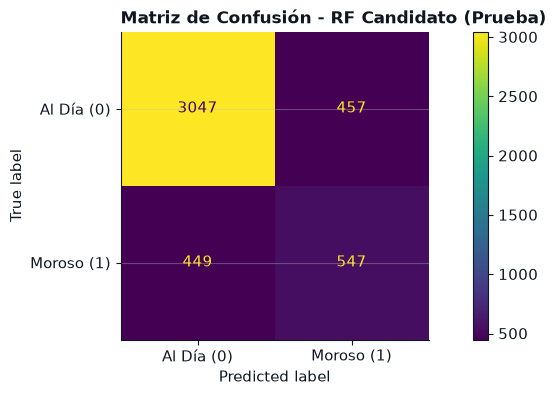

In [11]:
# Espacio de resolución — C8 — evaluación final
# 1. Separar predictores y objetivo
X_prueba = prueba[PREDICTORES]
y_prueba = prueba[OBJETIVO]

# 2. Evaluación de las referencias (Umbral 0.5)
# El Dummy ya predecía 0 siempre.
preds_dummy = dummy.predict(X_prueba)

# El Árbol solo requiere aplicar la tubería que ajustamos en C6
preds_arbol = pipeline_arbol.predict(X_prueba)

# 3. Evaluación del modelo candidato congelado en C7 (Random Forest, max_depth=None, Umbral 0.3)
probs_prueba = pipe_rf.predict_proba(X_prueba)[:, 1]
preds_candidato = (probs_prueba >= 0.3).astype(int)

# 4. Tabla comparativa final
resultados_finales = [
    {
        'Modelo': 'Dummy (Referencia)',
        'F1': f1_score(y_prueba, preds_dummy, zero_division=0),
        'Precisión': precision_score(y_prueba, preds_dummy, zero_division=0),
        'Sensibilidad': recall_score(y_prueba, preds_dummy, zero_division=0),
        'Exactitud': accuracy_score(y_prueba, preds_dummy)
    },
    {
        'Modelo': 'Árbol PAY_0 (Referencia)',
        'F1': f1_score(y_prueba, preds_arbol, zero_division=0),
        'Precisión': precision_score(y_prueba, preds_arbol, zero_division=0),
        'Sensibilidad': recall_score(y_prueba, preds_arbol, zero_division=0),
        'Exactitud': accuracy_score(y_prueba, preds_arbol)
    },
    {
        'Modelo': 'Candidato RF (Umbral 0.3)',
        'F1': f1_score(y_prueba, preds_candidato, zero_division=0),
        'Precisión': precision_score(y_prueba, preds_candidato, zero_division=0),
        'Sensibilidad': recall_score(y_prueba, preds_candidato, zero_division=0),
        'Exactitud': accuracy_score(y_prueba, preds_candidato)
    }
]

df_prueba = pd.DataFrame(resultados_finales)
display(df_prueba.round(4))

# 5. Gráfico de la Matriz de Confusión
cm = confusion_matrix(y_prueba, preds_candidato)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Al Día (0)', 'Moroso (1)']
)

disp.plot(values_format='d')
plt.title('Matriz de Confusión - RF Candidato (Prueba)')
plt.show()

**Interpretación:**

Al evaluar el conjunto de prueba, observamos que el modelo Random Forest con umbral 0.3 presenta el mayor F1 (0.5470) pero una exactitud (0.7987) menor a la del Árbol de referencia. Esto ocurre porque la exactitud se ve inflada artificialmente por la clase mayoritaria (clientes al día). Al bajar el umbral a 0.3 para priorizar la detección de morosos, aumentamos significativamente los Falsos Positivos (457 casos, sacrificando exactitud global) pero logramos capturar a más morosos reales (Sensibilidad de 0.5492 frente a 0.2711 del Árbol). En este escenario de negocio, el resultado que interesa es maximizar la detección del riesgo financiero (F1/Sensibilidad), asumiendo el costo operativo de los falsos positivos, en lugar de predecir correctamente la obviedad de los clientes cumplidores (Exactitud).

## 8.2 Consigna C9 — Dos errores y tres grupos

En prueba, construir para el candidato elegido una tabla de tamaño, positivos reales, F1, precisión y sensibilidad para tres grupos predefinidos según `PAY_0`: **−1 documentado**, **demora documentada (1 a 9)** y **código no documentado (−2 o 0)**. No llamar “al día” al tercer grupo. Usar `zero_division=0` como en C6 y señalar si alguna métrica carece de denominador; si un grupo no tiene registros, informar tamaño cero y métricas no calculables.

Elegir un falso positivo y un falso negativo del candidato elegido. Si no existe alguno de los dos tipos, informar su ausencia y analizar el tipo disponible, sin cambiar el modelo ni el umbral para provocar errores. Mostrar ID, objetivo, predicción y `PAY_0`, `LIMIT_BAL`, `BILL_AMT1`, `PAY_AMT1`; compararlos con patrones de entrenamiento. Ofrecer una explicación plausible, aclarando qué información falta para confirmarla. Explicar si el modelo de referencia del último estado (árbol de profundidad 1 sobre `PAY_0`, umbral 0,5) habría cometido el mismo error. No reajustar a partir de este análisis.

In [12]:
# Espacio de resolución — C9 — errores y grupos
# 1. TABLA DE MÉTRICAS SEGMENTADAS POR PAY_0
# ==========================================
# Definir las máscaras lógicas para los 3 grupos
m_grupo1 = X_prueba['PAY_0'] == -1
m_grupo2 = (X_prueba['PAY_0'] >= 1) & (X_prueba['PAY_0'] <= 9)
m_grupo3 = X_prueba['PAY_0'].isin([-2, 0])

grupos = [
    ('−1 documentado', m_grupo1),
    ('demora documentada (1 a 9)', m_grupo2),
    ('código no documentado (−2 o 0)', m_grupo3)
]

resultados_segmentados = []

for nombre, mascara in grupos:
    y_real_g = y_prueba[mascara]
    y_pred_g = preds_candidato[mascara]
    
    tamano = len(y_real_g)
    
    if tamano == 0:
        resultados_segmentados.append({
            'Grupo': nombre, 'Tamaño': 0, 'Positivos Reales': 0,
            'F1': 'No calculable', 'Precisión': 'No calculable', 'Sensibilidad': 'No calculable',
            'Nota': 'Grupo vacío'
        })
    else:
        pos_reales = sum(y_real_g)
        pos_predichos = sum(y_pred_g)
        
        # Avisos de denominador cero
        nota = []
        if pos_predichos == 0: nota.append("Precisión sin denominador (0 predicciones positivas)")
        if pos_reales == 0: nota.append("Sensibilidad sin denominador (0 positivos reales)")
        
        resultados_segmentados.append({
            'Grupo': nombre,
            'Tamaño': tamano,
            'Positivos Reales': pos_reales,
            'F1': f1_score(y_real_g, y_pred_g, zero_division=0),
            'Precisión': precision_score(y_real_g, y_pred_g, zero_division=0),
            'Sensibilidad': recall_score(y_real_g, y_pred_g, zero_division=0),
            'Nota': " - ".join(nota) if nota else "OK"
        })

df_segmentado = pd.DataFrame(resultados_segmentados)
print("=== MÉTRICAS SEGMENTADAS POR PAY_0 ===")
display(df_segmentado.round(4))

# ==========================================
# 2. EXTRACCIÓN DE FALSOS POSITIVOS Y NEGATIVOS
# ==========================================
# Crear un DataFrame de análisis con lo real, la predicción del RF y la del Árbol
analisis = X_prueba.copy()
analisis['id_cliente'] = prueba['id_cliente'] # ¡Acá rescatamos el ID real!
analisis['Objetivo_Real'] = y_prueba
analisis['Pred_RF_Candidato'] = preds_candidato
analisis['Pred_Arbol_Ref'] = preds_arbol # Lo calculamos en C8

# Agregamos 'id_cliente' al principio de la lista
columnas_mostrar = ['id_cliente', 'Objetivo_Real', 'Pred_RF_Candidato', 'Pred_Arbol_Ref', 'PAY_0', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']

# Falso Positivo (FP): Real = 0, Pred_RF = 1
fps = analisis[(analisis['Objetivo_Real'] == 0) & (analisis['Pred_RF_Candidato'] == 1)]
# Falso Negativo (FN): Real = 1, Pred_RF = 0
fns = analisis[(analisis['Objetivo_Real'] == 1) & (analisis['Pred_RF_Candidato'] == 0)]

columnas_mostrar = ['id_cliente', 'Objetivo_Real', 'Pred_RF_Candidato', 'Pred_Arbol_Ref', 'PAY_0', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']

print("\n=== ANÁLISIS DE ERRORES ===")
if len(fps) > 0:
    print("\nEjemplo de FALSO POSITIVO (El modelo dijo Moroso, pero pagó):")
    # Mostramos el primero (o podés usar .sample(1) para uno al azar)
    display(fps[columnas_mostrar].head(1))
else:
    print("\nNo existen Falsos Positivos en la predicción.")

if len(fns) > 0:
    print("\nEjemplo de FALSO NEGATIVO (El modelo dijo Al Día, pero fue Moroso):")
    display(fns[columnas_mostrar].head(1))
else:
    print("\nNo existen Falsos Negativos en la predicción.")

=== MÉTRICAS SEGMENTADAS POR PAY_0 ===


,Grupo,Tamaño,Positivos Reales,F1,Precisión,Sensibilidad,Nota
0,−1 documentado,863,135,0.3318,0.4205,0.2741,OK
1,demora documentada (1 a 9),1032,512,0.7037,0.5713,0.9160,OK
2,código no documentado (−2 o 0),2605,349,0.1847,0.4316,0.1175,OK



=== ANÁLISIS DE ERRORES ===

Ejemplo de FALSO POSITIVO (El modelo dijo Moroso, pero pagó):


,id_cliente,Objetivo_Real,Pred_RF_Candidato,Pred_Arbol_Ref,PAY_0,LIMIT_BAL,BILL_AMT1,PAY_AMT1
3,55,0,1,1,2,150000,46224,1600



Ejemplo de FALSO NEGATIVO (El modelo dijo Al Día, pero fue Moroso):


,id_cliente,Objetivo_Real,Pred_RF_Candidato,Pred_Arbol_Ref,PAY_0,LIMIT_BAL,BILL_AMT1,PAY_AMT1
19,174,1,0,0,1,50000,-709,0


**Interpretación:**

Falso Positivo (ID 55): El falso positivo seleccionado presenta `PAY_0=2`, por lo que el modelo identifica señales de riesgo, aunque el cliente finalmente no incumplió.  
Una explicación plausible es que existiera información financiera no observada que permitiera regularizar el pago, pero los datos disponibles no permiten confirmarlo.  

Falso Negativo (ID 174): El falso negativo presenta `PAY_0=1` y `BILL_AMT1=-709`, características que no permitieron al modelo anticipar el incumplimiento observado.  
Una explicación posible es que el modelo no captara algún cambio posterior en la situación financiera del cliente, para lo cual serían necesarios datos adicionales.  
El árbol de referencia cometió el mismo error tanto en el caso FP como en el caso FN.  

Estos ejemplos muestran que las variables disponibles permiten identificar patrones de riesgo, pero no explican por sí solas todos los incumplimientos individuales.


# 9. Responder y entregar evidencia reproducible
## 9.1 Consigna C10 — Síntesis y cierre

Redactar **200–300 palabras** que respondan la pregunta con resultados del candidato y del modelo de referencia del último estado, efecto del umbral, dos límites y una mejora futura razonable. Reconocer el carácter histórico de 2005, la ausencia de validación temporal y la semántica incompleta de algunos códigos. No convertir métricas en recomendaciones sobre clientes actuales ni provisiones normativas.

Antes de entregar: reiniciar kernel, ejecutar en orden, revisar interpretaciones y rutas relativas, conservar el registro de selección y citar las lecturas adicionales efectivamente consultadas. El siguiente soporte registra versiones.

In [13]:
display(pd.Series({paquete: version(paquete) for paquete in ["numpy", "pandas", "matplotlib", "scikit-learn"]}, name="version").to_frame())

,version
numpy,2.5.2
pandas,3.0.5
matplotlib,3.11.1
scikit-learn,1.9.1


**Interpretación.** Las versiones permiten reconstruir el entorno; la reproducibilidad también exige conservar los datos, las decisiones y el orden de evaluación.

**Respuesta:**

El Random Forest candidato presentó un mejor desempeño que el árbol de referencia basado únicamente en `PAY_0`. En prueba, el árbol obtuvo un F1 de 0,3905 y una sensibilidad de 0,2711, mientras que el candidato alcanzó un F1 de 0,5470 y una sensibilidad de 0,5492. La elección conjunta de Random Forest y umbral 0,3 permitió, en este conjunto de datos, detectar una mayor proporción de los incumplimientos, aunque con un mayor número de falsos positivos y una menor exactitud global. Por ello, F1 y sensibilidad resultan más informativos que la exactitud por sí sola para evaluar la detección de la clase positiva.

El análisis presenta dos limitaciones importantes. Primero, los datos corresponden a un escenario histórico de 2005 y la partición utilizada fue aleatoria, por lo que no se evaluó la estabilidad del modelo frente a cambios temporales o económicos. Segundo, los códigos de `PAY_0` −2 y 0 tienen una semántica incompleta en la fuente. Este grupo presenta una sensibilidad considerablemente inferior a la de los casos con demora documentada, por lo que constituye un segmento donde el modelo tiene mayores dificultades para detectar incumplimientos.

Como mejora futura, sería razonable incorporar variables derivadas que caractericen la evolución temporal de los saldos y pagos, en lugar de utilizar únicamente sus valores individuales. También sería conveniente realizar una validación temporal para evaluar si el desempeño se mantiene fuera del período histórico utilizado. Estas mejoras permitirían evaluar con mayor rigor la capacidad predictiva del modelo sin convertir sus resultados en recomendaciones sobre clientes actuales.

## Referencias y atribución

- Yeh, I. (2009). [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients). UCI Machine Learning Repository. DOI [10.24432/C55S3H](https://doi.org/10.24432/C55S3H). Datos bajo [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
- Yeh, I. y Lien, C. (2009). Artículo de origen identificado en la ficha UCI; su lectura no es obligatoria para resolver este parcial.

Adaptación docente: conversión de XLS a CSV, exclusión de demografía, renombrado de ID/objetivo y particiones estratificadas. No se modificaron importes ni estados. `FUENTES_Y_LICENCIAS.md` detalla la preparación y sus límites.